In [1]:
!pip install scikit-learn seaborn matplotlib pandas

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
from google.colab import files
uploaded = files.upload()

Saving german.data to german (1).data


In [9]:
columns = [
    'Status_Checking_Acc',
    'Duration',
    'Credit_History',
    'Purpose',
    'Credit_Amount',
    'Savings_Account',
    'Employment_Since',
    'Installment_Rate',
    'Personal_Status_Sex',
    'Other_Debtors',
    'Residence_Since',
    'Property',
    'Age',
    'Other_Installment_Plans',
    'Housing',
    'Existing_Credits',
    'Job',
    'People_Liable',
    'Telephone',
    'Foreign_Worker',
    'Target'
]

In [10]:
df = pd.read_csv(
    'german.data',
    sep=' ',
    header=None,
    names=columns
)

In [11]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 Rows:
  Status_Checking_Acc  Duration Credit_History Purpose  Credit_Amount  \
0                 A11         6            A34     A43           1169   
1                 A12        48            A32     A43           5951   
2                 A14        12            A34     A46           2096   
3                 A11        42            A32     A42           7882   
4                 A11        24            A33     A40           4870   

  Savings_Account Employment_Since  Installment_Rate Personal_Status_Sex  \
0             A65              A75                 4                 A93   
1             A61              A73                 2                 A92   
2             A61              A74                 2                 A93   
3             A61              A74                 2                 A93   
4             A61              A73                 3                 A93   

  Other_Debtors  ...  Property Age  Other_Installment_Plans Housing  \
0          A101  ..

In [12]:
df['Target'] = df['Target'].replace({
    1: 1,
    2: 0
})

In [13]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [14]:
X = df.drop('Target', axis=1)
y = df['Target']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [18]:
print("\n================ MODEL PERFORMANCE ================\n")

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print("ROC AUC   :", roc_auc_score(y_test, y_prob))


================ MODEL PERFORMANCE ================

Accuracy  : 0.79
Precision : 0.8113207547169812
Recall    : 0.9148936170212766
F1 Score  : 0.86
ROC AUC   : 0.8231758624834716


In [19]:
print("\n================ CLASSIFICATION REPORT ================\n")

print(classification_report(y_test, y_pred))


================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       0.71      0.49      0.58        59
           1       0.81      0.91      0.86       141

    accuracy                           0.79       200
   macro avg       0.76      0.70      0.72       200
weighted avg       0.78      0.79      0.78       200



In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:\n")
print(importance.head(10))


Top Important Features:

                Feature  Importance
4         Credit_Amount    0.129453
12                  Age    0.107786
0   Status_Checking_Acc    0.101983
1              Duration    0.094280
3               Purpose    0.069089
2        Credit_History    0.063747
6      Employment_Since    0.054434
5       Savings_Account    0.048103
11             Property    0.044579
10      Residence_Since    0.043331


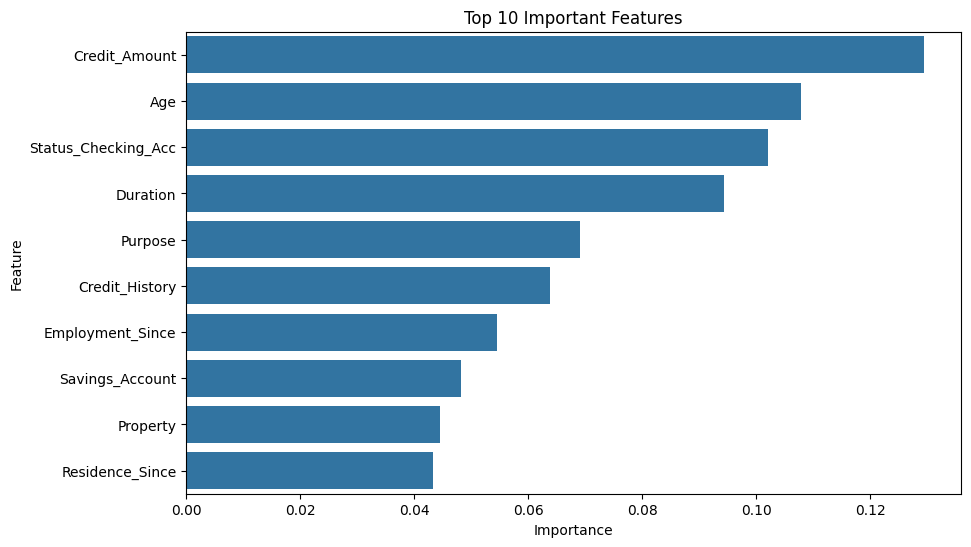

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()